In [120]:
import polars as pl 


In [121]:
data = pl.read_csv("CleanedTextSocialDistanceFeb27_sentiment_conv_full.csv")

data.describe()


statistic,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,social_distance_score,social_distance_binary,conversation_id,SEQ,ASEQ,sentiment_positive_prob,sentiment_negative_prob,sentiment_binary
str,f64,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",2.795015e6,"""2795015""",2.795015e6,"""2795015""","""2795014""","""1760365""",2.003416e6,2.795015e6,2.795015e6,2.795015e6,2.795015e6,1.52244e6,2.795015e6,2.795015e6,2.795015e6
"""null_count""",0.0,"""0""",0.0,"""0""","""1""","""1034650""",791599.0,0.0,0.0,0.0,0.0,1.272575e6,0.0,0.0,0.0
"""mean""",1.5048e6,null,0.544698,null,null,null,1.4633e6,0.685362,0.965799,1.4955e6,5.859484,4.388272,0.221994,0.329757,0.467203
"""std""",861589.036739,null,null,null,null,null,866508.281812,0.087444,0.181746,862227.391773,30.277474,26.816573,0.306674,0.351964,0.498923
"""min""",1.0,"""10026""",0.0,"""Fri Apr 01 17:37:48 +0000 2016""","""0""","""1""",1.0,0.059476,0.0,1.0,1.0,1.0,0.003157,0.000826,0.0
"""25%""",760444.0,null,null,null,null,null,715806.0,0.6364931,1.0,750823.0,1.0,1.0,0.016057,0.016517,0.0
"""50%""",1.508158e6,null,null,null,null,null,1.440204e6,0.696809,1.0,1.493377e6,2.0,1.0,0.0652411,0.1311977,0.0
"""75%""",2.253387e6,null,null,null,null,null,2.22083e6,0.7468816,1.0,2.243975e6,4.0,3.0,0.2881441,0.696523,1.0
"""max""",2.98795e6,"""sprintcare""",1.0,"""Wed Sep 28 18:06:15 +0000 2016""","""🧟‍♂️ 🧠 nom nom nom""","""99998,99999""",2.98795e6,0.9531033,1.0,2.987949e6,1344.0,1248.0,0.992923,0.96953,1.0


 Reindex dataframe by conversation IDs.

In [122]:
conversation_data = data.group_by(["conversation_id"]).agg(pl.all())
# conversation_ID n | Inbound = 1 | ...
# conversation_ID n | Inbound = 0 | ...

#conversation_data.describe()
conversation_data.head()


conversation_id,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,social_distance_score,social_distance_binary,SEQ,ASEQ,sentiment_positive_prob,sentiment_negative_prob,sentiment_binary
i64,list[i64],list[str],list[bool],list[str],list[str],list[str],list[f64],list[f64],list[i64],list[i64],list[f64],list[f64],list[f64],list[i64]
2609050,"[2609051, 2609050]","[""628698"", ""UPSHelp""]","[true, false]","[""Mon Oct 30 21:38:40 +0000 2017"", ""Mon Oct 30 21:55:01 +0000 2017""]","[""they send me a tracking number w 2nd day air for the iphone and say it’ll be here friday how many hours are in a day for you 👨🏾‍💻"", ""lets see whats going on dm your tracking number for further assistance bo""]","[""2609050"", null]","[null, 2.609051e6]","[0.7171379, 0.685194]","[1, 1]","[1, 2]","[1.0, null]","[0.099671, 0.04128]","[0.020393, 0.023304]","[1, 1]"
2218948,"[2218949, 2218948]","[""648199"", ""SpotifyCares""]","[true, false]","[""Fri Nov 10 09:21:26 +0000 2017"", ""Fri Nov 10 11:27:51 +0000 2017""]","[""smoke and mirrors by demi lovato really needs to be on"", ""hi there fingers crossed well be able to have it soon but theres info about spotify content here ny""]","[""2218948"", null]","[null, 2.218949e6]","[0.724894, 0.6936492]","[1, 1]","[1, 2]","[1.0, null]","[0.6775875, 0.8457168]","[0.019968, 0.002877]","[1, 1]"
378443,"[378444, 378443]","[""205810"", ""AmazonHelp""]","[true, false]","[""Mon Oct 09 04:12:59 +0000 2017"", ""Mon Oct 09 05:28:00 +0000 2017""]","[""any plans to add malayalam movies in prime video"", ""regional content is an integral part of our content in india please stay tuned as we expand our content selection rd""]","[""378443"", null]","[null, 378444.0]","[0.733176, 0.6330086]","[1, 1]","[1, 2]","[1.0, null]","[0.097099, 0.6408555]","[0.018027, 0.004539]","[1, 1]"
2465128,"[2465132, 2465130, … 2465128]","[""705459"", ""AskPlayStation"", … ""AskPlayStation""]","[true, false, … false]","[""Sun Oct 29 17:28:58 +0000 2017"", ""Sun Oct 29 19:14:46 +0000 2017"", … ""Sun Oct 29 19:19:09 +0000 2017""]","[""i need to remotely deactivate my ps3s so i can activate the one i have but there is no button for it pleasehelp"", ""sure we can help you can deactivate your account using a pc following these steps"", … ""if you are experiencing difficulties with the deactivation fill out our console deactivation web form""]","[""2465130"", ""2465129,2465131"", … null]","[null, 2.465132e6, … 2.465129e6]","[0.701532, 0.760708, … 0.7593634]","[1, 1, … 1]","[1, 2, … 5]","[1.0, null, … null]","[0.026286, 0.287491, … 0.03396]","[0.6190755, 0.017106, … 0.235673]","[0, 1, … 0]"
1509666,"[1509668, 1509666, 1509667]","[""470406"", ""GWRHelp"", ""470406""]","[true, false, true]","[""Fri Nov 03 14:21:23 +0000 2017"", ""Fri Nov 03 14:24:12 +0000 2017"", ""Fri Nov 03 14:28:20 +0000 2017""]","[""not happy that only 2 coaches in use and i have an ankle i jury coaches very packed"", ""hi sorry for any discomfort which train are you on andy"", ""1414 redhill reading""]","[""1509666"", ""1509667"", null]","[null, 1.509668e6, 1.509666e6]","[0.526991, 0.6943179, 0.5160942]","[1, 1, 1]","[1, 2, 3]","[1.0, null, 2.0]","[0.008944, 0.021982, 0.105771]","[0.8807933, 0.42961, 0.038168]","[0, 0, 1]"


 (1) Does Concrete answers take a longer time?

 Side note: exploding is suboptimal, but simple enough for our purposes since these conversations aren't going to be particularly large

In [123]:
# (a) Time Difference until first support tweet after initial customer tweet
conversationsWithSupportResponses = conversation_data.filter(
    pl.col("inbound").list.eval(pl.element() == 0).list.any()
)

timeToFirstCustomerSupport = (conversationsWithSupportResponses
    .explode(["inbound", "created_at"])
    .with_columns(pl.col("created_at").str.strptime(pl.Datetime, "%a %b %d %H:%M:%S %z %Y"))
    .group_by("conversation_id")
    .agg((pl.col("created_at").filter(pl.col("inbound") == 0).min() - 
         pl.col("created_at").filter(pl.col("inbound") == 1).min())
         .dt.total_seconds()
         .alias("time_to_support"))
)




In [124]:
print(len(conversation_data), len(conversationsWithSupportResponses))
len(conversationsWithSupportResponses) - len(conversation_data)


798206 797339


-867

In [125]:


averageTimeToFirstResponse = timeToFirstCustomerSupport.select(pl.col("time_to_support").mean())
#print(f"Average time to customer support response: {averageTimeToResponse} seconds")

timeToFirstCustomerSupport.describe()

# there's some bogus data still, min = -2.2427e8; max = 2.41937519e8 seconds?
# trim out 5th and 95th percentiles to see if that works. Check data tomorrow.


statistic,conversation_id,time_to_support
str,f64,f64
"""count""",797339.0,795389.0
"""null_count""",0.0,1950.0
"""mean""",1.5690e6,35210.670585
"""std""",852602.505188,1.6197e6
"""min""",1.0,-2.2427e8
"""25%""",832139.0,405.0
"""50%""",1.627478e6,1555.0
"""75%""",2.296888e6,8404.0
"""max""",2.987949e6,2.41937519e8


In [126]:
p5 = timeToFirstCustomerSupport["time_to_support"].quantile(0.05)
p95 = timeToFirstCustomerSupport["time_to_support"].quantile(0.95)

print(f"5th percentile: {p5 / 60:.1f} minutes")
print(f"95th percentile: {p95 / 60:.1f} minutes")

timeToFirstCustomerSupport_trimmed = timeToFirstCustomerSupport.filter(
    (pl.col("time_to_support") >= p5) &
    (pl.col("time_to_support") <= p95)
)
timeToFirstCustomerSupport_trimmed.describe()


5th percentile: 1.6 minutes
95th percentile: 1359.5 minutes


statistic,conversation_id,time_to_support
str,f64,f64
"""count""",715978.0,715978.0
"""null_count""",0.0,0.0
"""mean""",1.5713e6,7447.399396
"""std""",849879.638723,13754.331171
"""min""",11.0,97.0
"""25%""",841034.0,463.0
"""50%""",1.630699e6,1554.0
"""75%""",2.293108e6,6941.0
"""max""",2.987949e6,81571.0


 Average duration per support tweet

In [127]:
# not what you asked for: average time between support responses (time between first and last support response divided by number of support responses)
averageTimeBetweenSupportResponse = (conversationsWithSupportResponses
    .explode(["inbound", "created_at"])
    .with_columns(
        pl.col("created_at").str.strptime(pl.Datetime, "%a %b %d %H:%M:%S %z %Y")
    )
    .filter(pl.col("inbound") == 0)  
    .group_by("conversation_id")
    .agg([
        pl.col("created_at").min().alias("first_support"),
        pl.col("created_at").max().alias("last_support"),
        pl.col("created_at").count().alias("support_tweet_count")
    ])
    .filter(pl.col("support_tweet_count") > 1)  # Need at least 2 tweets
    .with_columns([
        # Time span / (number of tweets - 1) = average gap
        ((pl.col("last_support") - pl.col("first_support")).dt.total_seconds() / 
         (pl.col("support_tweet_count") - 1))
        .alias("avg_seconds_between_support_tweets")
    ])
)

print(averageTimeBetweenSupportResponse.select([
    "conversation_id",
    "support_tweet_count",
    "avg_seconds_between_support_tweets"
]).head())


shape: (5, 3)
┌─────────────────┬─────────────────────┬─────────────────────────────────┐
│ conversation_id ┆ support_tweet_count ┆ avg_seconds_between_support_tw… │
│ ---             ┆ ---                 ┆ ---                             │
│ i64             ┆ u32                 ┆ f64                             │
╞═════════════════╪═════════════════════╪═════════════════════════════════╡
│ 445304          ┆ 5                   ┆ 2751.5                          │
│ 1222465         ┆ 2                   ┆ 51718.0                         │
│ 1479661         ┆ 2                   ┆ 8111.0                          │
│ 2411885         ┆ 5                   ┆ 23406.25                        │
│ 284980          ┆ 2                   ┆ 987.0                           │
└─────────────────┴─────────────────────┴─────────────────────────────────┘


In [128]:
p5 = averageTimeBetweenSupportResponse["avg_seconds_between_support_tweets"].quantile(0.05)
p95 = averageTimeBetweenSupportResponse["avg_seconds_between_support_tweets"].quantile(0.95)

avg_trimmed = averageTimeBetweenSupportResponse.filter(
    (pl.col("avg_seconds_between_support_tweets") >= p5) &
    (pl.col("avg_seconds_between_support_tweets") <= p95)
)

print("Trimmed statistics (middle 90%):")
print(avg_trimmed["avg_seconds_between_support_tweets"].describe())


Trimmed statistics (middle 90%):
shape: (9, 2)
┌────────────┬──────────────┐
│ statistic  ┆ value        │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ count      ┆ 228174.0     │
│ null_count ┆ 0.0          │
│ mean       ┆ 16003.530537 │
│ std        ┆ 30490.195104 │
│ min        ┆ 7.0          │
│ 25%        ┆ 625.0        │
│ 50%        ┆ 2320.0       │
│ 75%        ┆ 14052.5      │
│ max        ┆ 172804.0     │
└────────────┴──────────────┘


In [129]:
averageTimePerTweet = (conversationsWithSupportResponses
    .explode(["inbound", "created_at"])
    .with_columns(
        pl.col("created_at").str.strptime(pl.Datetime, "%a %b %d %H:%M:%S %z %Y")
    )
    .group_by("conversation_id")
    .agg([
        pl.col("created_at").min().alias("first_tweet"),
        pl.col("created_at").max().alias("last_tweet"),
        pl.col("created_at").count().alias("total_tweets")
    ])
    .with_columns([
        ((pl.col("last_tweet") - pl.col("first_tweet")).dt.total_seconds() / 
         pl.col("total_tweets"))
        .alias("avg_seconds_between_all_tweets")
    ])
)  

print(averageTimePerTweet.select([
    "conversation_id",
    "total_tweets",
    "avg_seconds_between_all_tweets"
]).head())  

averageTimePerTweet.describe()


shape: (5, 3)
┌─────────────────┬──────────────┬────────────────────────────────┐
│ conversation_id ┆ total_tweets ┆ avg_seconds_between_all_tweets │
│ ---             ┆ ---          ┆ ---                            │
│ i64             ┆ u32          ┆ f64                            │
╞═════════════════╪══════════════╪════════════════════════════════╡
│ 1067134         ┆ 2            ┆ 4175.0                         │
│ 1696964         ┆ 4            ┆ 178.75                         │
│ 1502857         ┆ 3            ┆ 2200.666667                    │
│ 1447158         ┆ 2            ┆ 348.5                          │
│ 23351           ┆ 5            ┆ 64976.2                        │
└─────────────────┴──────────────┴────────────────────────────────┘


statistic,conversation_id,first_tweet,last_tweet,total_tweets,avg_seconds_between_all_tweets
str,f64,str,str,f64,f64
"""count""",797339.0,"""797339""","""797339""",797339.0,797339.0
"""null_count""",0.0,"""0""","""0""",0.0,0.0
"""mean""",1.5690e6,"""2017-11-02 18:21:52.094687+00:…","""2017-11-04 06:20:53.105001+00:…",3.50296,29236.233807
"""std""",852602.505188,null,null,5.019364,578496.386742
"""min""",1.0,"""2008-05-08 20:13:59+00:00""","""2014-12-19 15:22:13+00:00""",1.0,0.0
"""25%""",832139.0,"""2017-10-19 14:15:34+00:00""","""2017-10-20 03:02:38+00:00""",2.0,295.0
"""50%""",1.627478e6,"""2017-11-03 20:31:59+00:00""","""2017-11-04 13:07:13+00:00""",2.0,1190.0
"""75%""",2.296888e6,"""2017-11-19 01:10:18+00:00""","""2017-11-19 20:33:27+00:00""",4.0,6840.5
"""max""",2.987949e6,"""2017-12-03 23:04:17+00:00""","""2017-12-03 23:14:01+00:00""",1344.0,8.0646e7


In [130]:
p5 = averageTimePerTweet["avg_seconds_between_all_tweets"].quantile(0.05)
p95 = averageTimePerTweet["avg_seconds_between_all_tweets"].quantile(0.95)

avg_trimmed = averageTimePerTweet.filter(
    (pl.col("avg_seconds_between_all_tweets") >= p5) &
    (pl.col("avg_seconds_between_all_tweets") <= p95)
)

print("Trimmed statistics (middle 90%):")
print(avg_trimmed["avg_seconds_between_all_tweets"].describe())


Trimmed statistics (middle 90%):
shape: (9, 2)
┌────────────┬──────────────┐
│ statistic  ┆ value        │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ count      ┆ 717709.0     │
│ null_count ┆ 0.0          │
│ mean       ┆ 5517.071238  │
│ std        ┆ 9736.65825   │
│ min        ┆ 68.5         │
│ 25%        ┆ 337.5        │
│ 50%        ┆ 1189.666667  │
│ 75%        ┆ 5538.0       │
│ max        ┆ 56295.333333 │
└────────────┴──────────────┘


 Combining tables with original data

In [131]:
conversation_data_with_time_stats = (conversation_data
    # Join time to first support response
    .join(
        timeToFirstCustomerSupport_trimmed.select([
            "conversation_id",
            "time_to_support"
        ]),
        on="conversation_id",
        how="left"
    )
    # Join average time between all tweets
    .join(
        avg_trimmed.select([
            "conversation_id",
            "avg_seconds_between_all_tweets",
            "total_tweets"
        ]),
        on="conversation_id",
        how="left"
    )
    # Join average time between support tweets
    #.join(
    #    averageTimeBetweenSupportResponse.select([
    #        "conversation_id",
    #        "avg_seconds_between_support_tweets"
    #    ]),
    #    on="conversation_id",
    #    how="left"
    #)
)

# cull conversations that data wasn't collected on (appeared on 5th or 95th percentile on one of them)
conversation_data_with_time_stats_trimmed = conversation_data_with_time_stats.filter(
    pl.col("time_to_support").is_not_null() &
    pl.col("avg_seconds_between_all_tweets").is_not_null()
)   


In [132]:
conversation_data_with_time_stats_trimmed.describe()
conversation_data_with_time_stats_trimmed.head()


conversation_id,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,social_distance_score,social_distance_binary,SEQ,ASEQ,sentiment_positive_prob,sentiment_negative_prob,sentiment_binary,time_to_support,avg_seconds_between_all_tweets,total_tweets
i64,list[i64],list[str],list[bool],list[str],list[str],list[str],list[f64],list[f64],list[i64],list[i64],list[f64],list[f64],list[f64],list[i64],i64,f64,u32
2609050,"[2609051, 2609050]","[""628698"", ""UPSHelp""]","[true, false]","[""Mon Oct 30 21:38:40 +0000 2017"", ""Mon Oct 30 21:55:01 +0000 2017""]","[""they send me a tracking number w 2nd day air for the iphone and say it’ll be here friday how many hours are in a day for you 👨🏾‍💻"", ""lets see whats going on dm your tracking number for further assistance bo""]","[""2609050"", null]","[null, 2.609051e6]","[0.7171379, 0.685194]","[1, 1]","[1, 2]","[1.0, null]","[0.099671, 0.04128]","[0.020393, 0.023304]","[1, 1]",981,490.5,2
2218948,"[2218949, 2218948]","[""648199"", ""SpotifyCares""]","[true, false]","[""Fri Nov 10 09:21:26 +0000 2017"", ""Fri Nov 10 11:27:51 +0000 2017""]","[""smoke and mirrors by demi lovato really needs to be on"", ""hi there fingers crossed well be able to have it soon but theres info about spotify content here ny""]","[""2218948"", null]","[null, 2.218949e6]","[0.724894, 0.6936492]","[1, 1]","[1, 2]","[1.0, null]","[0.6775875, 0.8457168]","[0.019968, 0.002877]","[1, 1]",7585,3792.5,2
378443,"[378444, 378443]","[""205810"", ""AmazonHelp""]","[true, false]","[""Mon Oct 09 04:12:59 +0000 2017"", ""Mon Oct 09 05:28:00 +0000 2017""]","[""any plans to add malayalam movies in prime video"", ""regional content is an integral part of our content in india please stay tuned as we expand our content selection rd""]","[""378443"", null]","[null, 378444.0]","[0.733176, 0.6330086]","[1, 1]","[1, 2]","[1.0, null]","[0.097099, 0.6408555]","[0.018027, 0.004539]","[1, 1]",4501,2250.5,2
2465128,"[2465132, 2465130, … 2465128]","[""705459"", ""AskPlayStation"", … ""AskPlayStation""]","[true, false, … false]","[""Sun Oct 29 17:28:58 +0000 2017"", ""Sun Oct 29 19:14:46 +0000 2017"", … ""Sun Oct 29 19:19:09 +0000 2017""]","[""i need to remotely deactivate my ps3s so i can activate the one i have but there is no button for it pleasehelp"", ""sure we can help you can deactivate your account using a pc following these steps"", … ""if you are experiencing difficulties with the deactivation fill out our console deactivation web form""]","[""2465130"", ""2465129,2465131"", … null]","[null, 2.465132e6, … 2.465129e6]","[0.701532, 0.760708, … 0.7593634]","[1, 1, … 1]","[1, 2, … 5]","[1.0, null, … null]","[0.026286, 0.287491, … 0.03396]","[0.6190755, 0.017106, … 0.235673]","[0, 1, … 0]",6348,1322.2,5
1509666,"[1509668, 1509666, 1509667]","[""470406"", ""GWRHelp"", ""470406""]","[true, false, true]","[""Fri Nov 03 14:21:23 +0000 2017"", ""Fri Nov 03 14:24:12 +0000 2017"", ""Fri Nov 03 14:28:20 +0000 2017""]","[""not happy that only 2 coaches in use and i have an ankle i jury coaches very packed"", ""hi sorry for any discomfort which train are you on andy"", ""1414 redhill reading""]","[""1509666"", ""1509667"", null]","[null, 1.509668e6, 1.509666e6]","[0.526991, 0.6943179, 0.5160942]","[1, 1, 1]","[1, 2, 3]","[1.0, null, 2.0]","[0.008944, 0.021982, 0.105771]","[0.8807933, 0.42961, 0.038168]","[0, 0, 1]",169,139.0,3


 Plots for (1)

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt


In [134]:
# average concreteness of support tweets per conversation
support_social_distance = (conversation_data_with_time_stats_trimmed
    .explode(["inbound", "social_distance_score"])
    .filter(pl.col("inbound") == 0)
    .group_by("conversation_id")
    .agg(pl.col("social_distance_score").mean().alias("avg_social_distance_score_support"))
)

concreteness_data = conversation_data_with_time_stats_trimmed.join(
    support_social_distance.select([
        "conversation_id",
        "avg_social_distance_score_support"
    ]),
    on="conversation_id",
    how="left"
)

concreteness_data.describe()
concreteness_data.head()


conversation_id,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,social_distance_score,social_distance_binary,SEQ,ASEQ,sentiment_positive_prob,sentiment_negative_prob,sentiment_binary,time_to_support,avg_seconds_between_all_tweets,total_tweets,avg_social_distance_score_support
i64,list[i64],list[str],list[bool],list[str],list[str],list[str],list[f64],list[f64],list[i64],list[i64],list[f64],list[f64],list[f64],list[i64],i64,f64,u32,f64
2609050,"[2609051, 2609050]","[""628698"", ""UPSHelp""]","[true, false]","[""Mon Oct 30 21:38:40 +0000 2017"", ""Mon Oct 30 21:55:01 +0000 2017""]","[""they send me a tracking number w 2nd day air for the iphone and say it’ll be here friday how many hours are in a day for you 👨🏾‍💻"", ""lets see whats going on dm your tracking number for further assistance bo""]","[""2609050"", null]","[null, 2.609051e6]","[0.7171379, 0.685194]","[1, 1]","[1, 2]","[1.0, null]","[0.099671, 0.04128]","[0.020393, 0.023304]","[1, 1]",981,490.5,2,0.685194
2218948,"[2218949, 2218948]","[""648199"", ""SpotifyCares""]","[true, false]","[""Fri Nov 10 09:21:26 +0000 2017"", ""Fri Nov 10 11:27:51 +0000 2017""]","[""smoke and mirrors by demi lovato really needs to be on"", ""hi there fingers crossed well be able to have it soon but theres info about spotify content here ny""]","[""2218948"", null]","[null, 2.218949e6]","[0.724894, 0.6936492]","[1, 1]","[1, 2]","[1.0, null]","[0.6775875, 0.8457168]","[0.019968, 0.002877]","[1, 1]",7585,3792.5,2,0.6936492
378443,"[378444, 378443]","[""205810"", ""AmazonHelp""]","[true, false]","[""Mon Oct 09 04:12:59 +0000 2017"", ""Mon Oct 09 05:28:00 +0000 2017""]","[""any plans to add malayalam movies in prime video"", ""regional content is an integral part of our content in india please stay tuned as we expand our content selection rd""]","[""378443"", null]","[null, 378444.0]","[0.733176, 0.6330086]","[1, 1]","[1, 2]","[1.0, null]","[0.097099, 0.6408555]","[0.018027, 0.004539]","[1, 1]",4501,2250.5,2,0.6330086
2465128,"[2465132, 2465130, … 2465128]","[""705459"", ""AskPlayStation"", … ""AskPlayStation""]","[true, false, … false]","[""Sun Oct 29 17:28:58 +0000 2017"", ""Sun Oct 29 19:14:46 +0000 2017"", … ""Sun Oct 29 19:19:09 +0000 2017""]","[""i need to remotely deactivate my ps3s so i can activate the one i have but there is no button for it pleasehelp"", ""sure we can help you can deactivate your account using a pc following these steps"", … ""if you are experiencing difficulties with the deactivation fill out our console deactivation web form""]","[""2465130"", ""2465129,2465131"", … null]","[null, 2.465132e6, … 2.465129e6]","[0.701532, 0.760708, … 0.7593634]","[1, 1, … 1]","[1, 2, … 5]","[1.0, null, … null]","[0.026286, 0.287491, … 0.03396]","[0.6190755, 0.017106, … 0.235673]","[0, 1, … 0]",6348,1322.2,5,0.7600357
1509666,"[1509668, 1509666, 1509667]","[""470406"", ""GWRHelp"", ""470406""]","[true, false, true]","[""Fri Nov 03 14:21:23 +0000 2017"", ""Fri Nov 03 14:24:12 +0000 2017"", ""Fri Nov 03 14:28:20 +0000 2017""]","[""not happy that only 2 coaches in use and i have an ankle i jury coaches very packed"", ""hi sorry for any discomfort which train are you on andy"", ""1414 redhill reading""]","[""1509666"", ""1509667"", null]","[null, 1.509668e6, 1.509666e6]","[0.526991, 0.6943179, 0.5160942]","[1, 1, 1]","[1, 2, 3]","[1.0, null, 2.0]","[0.008944, 0.021982, 0.105771]","[0.8807933, 0.42961, 0.038168]","[0, 0, 1]",169,139.0,3,0.6943179


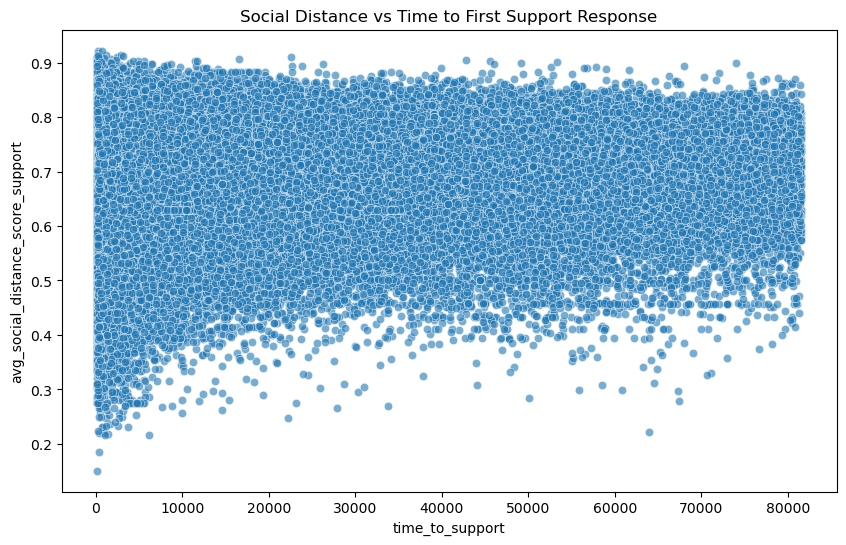

In [143]:
# concreteness of support tweets over time to first support response
x = concreteness_data.select("time_to_support").to_series()
y = concreteness_data.select("avg_social_distance_score_support").to_series()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x, y=y, alpha=0.6)
plt.title('Social Distance vs Time to First Support Response')

plt.savefig("social_distance_vs_time_to_support.png")
plt.show()


# weird plot.


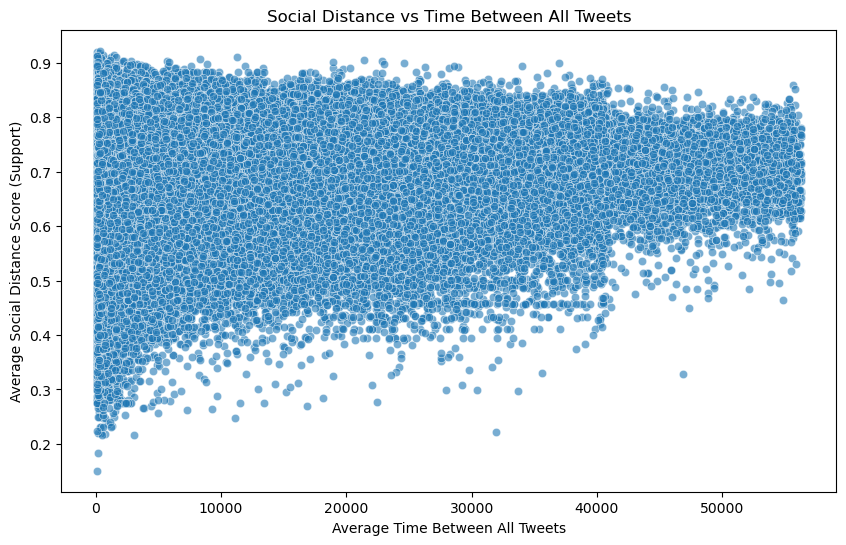

In [144]:
# concreteness of support tweets over average time between all tweets

x = concreteness_data.select("avg_seconds_between_all_tweets").to_series()
y = concreteness_data.select("avg_social_distance_score_support").to_series()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x, y=y, alpha=0.6)
plt.title('Social Distance vs Time Between All Tweets')
plt.xlabel('Average Time Between All Tweets')
plt.ylabel('Average Social Distance Score (Support)')
plt.savefig("social_distance_vs_time_between_all_tweets.png")

plt.show()


In [145]:
# average customer sentiment per conversation
average_customer_sentiment = (conversation_data_with_time_stats_trimmed
    .explode(["inbound", "sentiment_positive_prob"])
    .filter(pl.col("inbound") == 1)
    .group_by("conversation_id")
    .agg(pl.col("sentiment_positive_prob").mean().alias("avg_sentiment_positive_prob"))
)

sentiment_data = conversation_data_with_time_stats_trimmed.join(
    average_customer_sentiment.select([
        "conversation_id",
        "avg_sentiment_positive_prob"
    ]),
    on="conversation_id",
    how="left"
)

sentiment_data.describe()
sentiment_data.head()



conversation_id,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,social_distance_score,social_distance_binary,SEQ,ASEQ,sentiment_positive_prob,sentiment_negative_prob,sentiment_binary,time_to_support,avg_seconds_between_all_tweets,total_tweets,avg_sentiment_positive_prob
i64,list[i64],list[str],list[bool],list[str],list[str],list[str],list[f64],list[f64],list[i64],list[i64],list[f64],list[f64],list[f64],list[i64],i64,f64,u32,f64
2609050,"[2609051, 2609050]","[""628698"", ""UPSHelp""]","[true, false]","[""Mon Oct 30 21:38:40 +0000 2017"", ""Mon Oct 30 21:55:01 +0000 2017""]","[""they send me a tracking number w 2nd day air for the iphone and say it’ll be here friday how many hours are in a day for you 👨🏾‍💻"", ""lets see whats going on dm your tracking number for further assistance bo""]","[""2609050"", null]","[null, 2.609051e6]","[0.7171379, 0.685194]","[1, 1]","[1, 2]","[1.0, null]","[0.099671, 0.04128]","[0.020393, 0.023304]","[1, 1]",981,490.5,2,0.099671
2218948,"[2218949, 2218948]","[""648199"", ""SpotifyCares""]","[true, false]","[""Fri Nov 10 09:21:26 +0000 2017"", ""Fri Nov 10 11:27:51 +0000 2017""]","[""smoke and mirrors by demi lovato really needs to be on"", ""hi there fingers crossed well be able to have it soon but theres info about spotify content here ny""]","[""2218948"", null]","[null, 2.218949e6]","[0.724894, 0.6936492]","[1, 1]","[1, 2]","[1.0, null]","[0.6775875, 0.8457168]","[0.019968, 0.002877]","[1, 1]",7585,3792.5,2,0.6775875
378443,"[378444, 378443]","[""205810"", ""AmazonHelp""]","[true, false]","[""Mon Oct 09 04:12:59 +0000 2017"", ""Mon Oct 09 05:28:00 +0000 2017""]","[""any plans to add malayalam movies in prime video"", ""regional content is an integral part of our content in india please stay tuned as we expand our content selection rd""]","[""378443"", null]","[null, 378444.0]","[0.733176, 0.6330086]","[1, 1]","[1, 2]","[1.0, null]","[0.097099, 0.6408555]","[0.018027, 0.004539]","[1, 1]",4501,2250.5,2,0.097099
2465128,"[2465132, 2465130, … 2465128]","[""705459"", ""AskPlayStation"", … ""AskPlayStation""]","[true, false, … false]","[""Sun Oct 29 17:28:58 +0000 2017"", ""Sun Oct 29 19:14:46 +0000 2017"", … ""Sun Oct 29 19:19:09 +0000 2017""]","[""i need to remotely deactivate my ps3s so i can activate the one i have but there is no button for it pleasehelp"", ""sure we can help you can deactivate your account using a pc following these steps"", … ""if you are experiencing difficulties with the deactivation fill out our console deactivation web form""]","[""2465130"", ""2465129,2465131"", … null]","[null, 2.465132e6, … 2.465129e6]","[0.701532, 0.760708, … 0.7593634]","[1, 1, … 1]","[1, 2, … 5]","[1.0, null, … null]","[0.026286, 0.287491, … 0.03396]","[0.6190755, 0.017106, … 0.235673]","[0, 1, … 0]",6348,1322.2,5,0.027126
1509666,"[1509668, 1509666, 1509667]","[""470406"", ""GWRHelp"", ""470406""]","[true, false, true]","[""Fri Nov 03 14:21:23 +0000 2017"", ""Fri Nov 03 14:24:12 +0000 2017"", ""Fri Nov 03 14:28:20 +0000 2017""]","[""not happy that only 2 coaches in use and i have an ankle i jury coaches very packed"", ""hi sorry for any discomfort which train are you on andy"", ""1414 redhill reading""]","[""1509666"", ""1509667"", null]","[null, 1.509668e6, 1.509666e6]","[0.526991, 0.6943179, 0.5160942]","[1, 1, 1]","[1, 2, 3]","[1.0, null, 2.0]","[0.008944, 0.021982, 0.105771]","[0.8807933, 0.42961, 0.038168]","[0, 0, 1]",169,139.0,3,0.057358


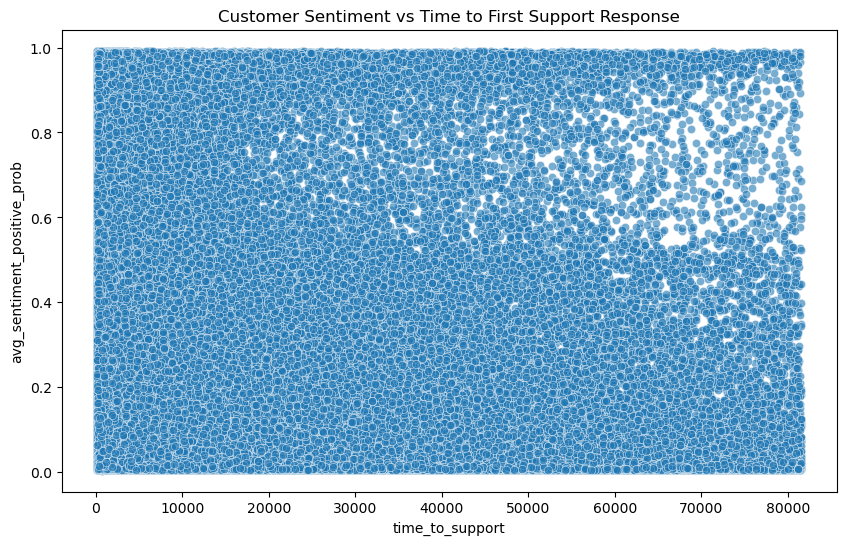

In [146]:
x = sentiment_data.select("time_to_support").to_series()
y = sentiment_data.select("avg_sentiment_positive_prob").to_series()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x, y=y, alpha=0.6)
plt.title('Customer Sentiment vs Time to First Support Response')
plt.savefig("sentiment_vs_time_to_support.png")
plt.show()


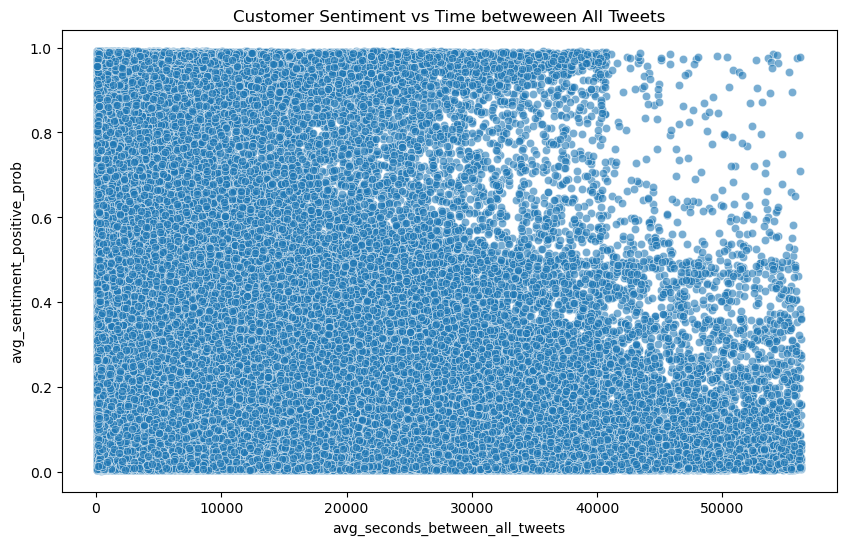

In [147]:
x = sentiment_data.select("avg_seconds_between_all_tweets").to_series()
y = sentiment_data.select("avg_sentiment_positive_prob").to_series()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x, y=y, alpha=0.6)
plt.title('Customer Sentiment vs Time betweween All Tweets')


plt.savefig("sentiment_vs_time_between_all_tweets.png")
plt.show()



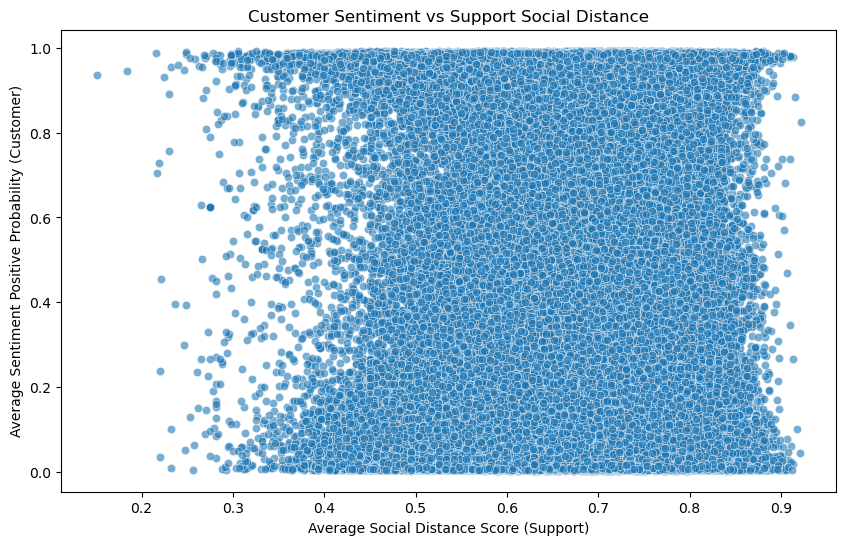

In [148]:
# More concrete answers means more satisfaction?

concrete_sentiment_data = (conversation_data_with_time_stats_trimmed
    .join(
        support_social_distance.select([
            "conversation_id",  
            "avg_social_distance_score_support"
        ]),
        on="conversation_id",
        how="left"
    )
    .join(
        average_customer_sentiment.select([
            "conversation_id",
            "avg_sentiment_positive_prob"
        ]),
        on="conversation_id",
        how="left"
    )
)

x = concrete_sentiment_data.select("avg_social_distance_score_support").to_series()
y = concrete_sentiment_data.select("avg_sentiment_positive_prob").to_series()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=x, y=y, alpha=0.6)
plt.title('Customer Sentiment vs Support Social Distance')
plt.xlabel('Average Social Distance Score (Support)')
plt.ylabel('Average Sentiment Positive Probability (Customer)')
plt.savefig("sentiment_vs_social_distance.png")
plt.show()



